<a href="https://colab.research.google.com/github/Pam-Pam29/WEMA-Women-s-Emergency-Medical-AI/blob/main/WEMA_Data%3DColab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# WEMA — Data & RAG Baseline (Colab)

**Women's Emergency Medical AI · Capstone notebook**

This notebook has two parts, with explanations throughout:

- **Part 1 — Data.** Loads and characterises the two labelled data assets: the clinical knowledge base (the documents that ground WEMA's answers) and the evaluation scenarios (the labelled test cases).
- **Part 2 — RAG baseline.** Connects to the real vector store, shows retrieval working end to end, and runs a baseline evaluation of the RAG system at its current settings.

> **Run order:** top to bottom. Run the setup cell first, then mount Drive. Edit the paths in the config cell to match your Drive folder.

---

## Setup

Install the packages WEMA's stack needs, then mount Google Drive so the notebook can reach your store and data files. **After the install, if prompted, restart the runtime once (Runtime → Restart), then re-run from here.**

In [1]:
!pip install -q langchain-community chromadb sentence-transformers openpyxl langchain-groq

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 86.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 554.3/554.3 kB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 74.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/2

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Configuration

These paths point into your project folder on Drive. Edit them if your folder is named or located differently. `COLLECTION_NAME` and `EMBEDDING_MODEL` match WEMA's `rag.py` exactly — they must, or retrieval reads the wrong store.

In [7]:
import os

PROJECT   = "/content/drive/MyDrive/WEMA-Women-s-Emergency-Medical-AI"
CHROMA_DIR      = f"{PROJECT}/knowledge_base"               # the persisted vector store
COLLECTION_NAME = "wema_maternal_health"                    # collection inside the store
EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"  # matches rag.py
SCENARIOS_PATH  = f"{PROJECT}/WEMA_Labeled_Dataset.xlsx"  # the 68 labelled scenarios

# WEMA chart palette
GREEN, CORAL, INK, GREY = "#1D9E75", "#D85A30", "#2C2C2A", "#888780"
BLUE, PLUM = "#3A7CA5", "#7B6D8D"

import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# sanity-check the paths exist before we rely on them
print("store folder exists:  ", os.path.isdir(CHROMA_DIR))
print("scenarios file exists:", os.path.isfile(SCENARIOS_PATH))

store folder exists:   True
scenarios file exists: True


---
# Part 1 — Data

WEMA rests on two labelled data assets. This part loads and characterises both.

## 1A. The knowledge base

The knowledge base is the set of clinical guidelines that ground WEMA's answers. Rather than letting the language model answer from memory, WEMA retrieves passages from these documents so every response is grounded in real WHO/ACOG guidance.

It is **19 curated documents**, split into **8,750 retrievable passages (chunks)** stored in a ChromaDB vector index. The cell below connects to that store and counts how many chunks each document contributed — which is the honest measure of the knowledge base, because it reflects what the system can actually retrieve, not just how many files exist.

In [4]:
import chromadb, collections

client = chromadb.PersistentClient(path=CHROMA_DIR)
col = client.get_collection(COLLECTION_NAME)
meta = col.get(include=["metadatas"])["metadatas"]

# chunks per source document (source stored as a full path; take the filename)
counts = collections.Counter(
    (m or {}).get("source", "?").replace("\\", "/").split("/")[-1] for m in meta
)
kb = (pd.DataFrame(counts.items(), columns=["document", "chunks"])
        .sort_values("chunks", ascending=False).reset_index(drop=True))
print(f"{len(kb)} documents · {kb['chunks'].sum()} chunks total")
kb

19 documents · 8750 chunks total


,document,chunks
0,9789241549356-eng.pdf,1611
1,WHO_Maternal_Guidelines_2025.pdf,1551
2,managing pregnany for midwife and docors.pdf,919
3,Clinical management of obstetric and neonatal ...,657
4,lee-et-al-2025-part-5-neonatal-resuscitation-2...,552
5,9789240115835-eng.pdf,447
6,WHO recommendations on antiplatelet agents for...,426
7,WHO recommendations Uterotonics for prevention...,340
8,Treatment of Perinatal Mental Health Condition...,319
9,Gestational_Hypertension_and_Preeclampsia_ACOG...,284


**Reading this:** the two large WHO guidelines contribute the most chunks. That is expected — chunk count tracks document length, so long consolidated guidelines naturally produce more passages than short statements. It is a known property of the index, not a weighting choice.

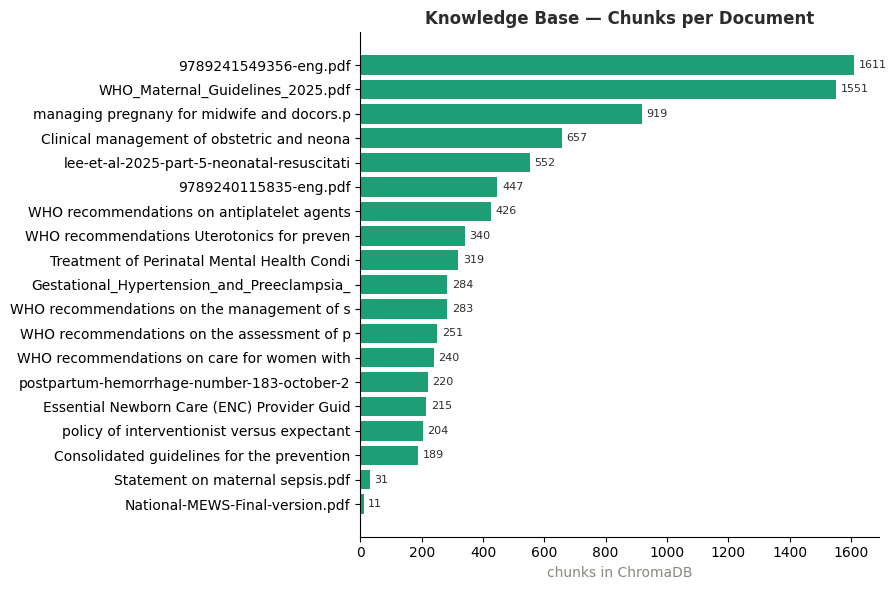

In [5]:
fig, ax = plt.subplots(figsize=(9,6))
d = kb.sort_values("chunks")
ax.barh(d["document"].str.slice(0,42), d["chunks"], color=GREEN)
for i,(v) in enumerate(d["chunks"]):
    ax.text(v+15, i, str(v), va="center", fontsize=8, color=INK)
ax.set_title("Knowledge Base — Chunks per Document", fontweight="bold", color=INK)
ax.set_xlabel("chunks in ChromaDB", color=GREY)
for s in ["top","right"]: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

## 1B. The evaluation scenarios

The scenarios are the labelled test cases used to evaluate WEMA: **68 cases across 17 emergency types**, each with a caller script, the expected correct home action, a risk level, and an alerting decision. These are the ground truth the system is measured against.

In [8]:
scen = pd.read_excel(SCENARIOS_PATH)
print(f"{len(scen)} scenarios · {len(scen.columns)} columns")
print("emergency types:", scen["emergency_type"].nunique())
scen[["scenario_id","emergency_type","severity","expected_risk_level","expected_sms_triggered"]].head()

68 scenarios · 39 columns
emergency types: 17


,scenario_id,emergency_type,severity,expected_risk_level,expected_sms_triggered
0,S001,Postpartum Haemorrhage,Critical,High,Yes
1,S002,Postpartum Haemorrhage,Critical,High,Yes
2,S003,Postpartum Haemorrhage,Critical,High,Yes
3,S004,Postpartum Haemorrhage,Moderate,Medium,No
4,S005,Postpartum Haemorrhage,Critical,High,Yes


**Distribution by emergency type** — the clinical breadth of the test set. Postpartum haemorrhage, sepsis, obstructed labour and the other leading direct causes of maternal death are represented most heavily, by design.

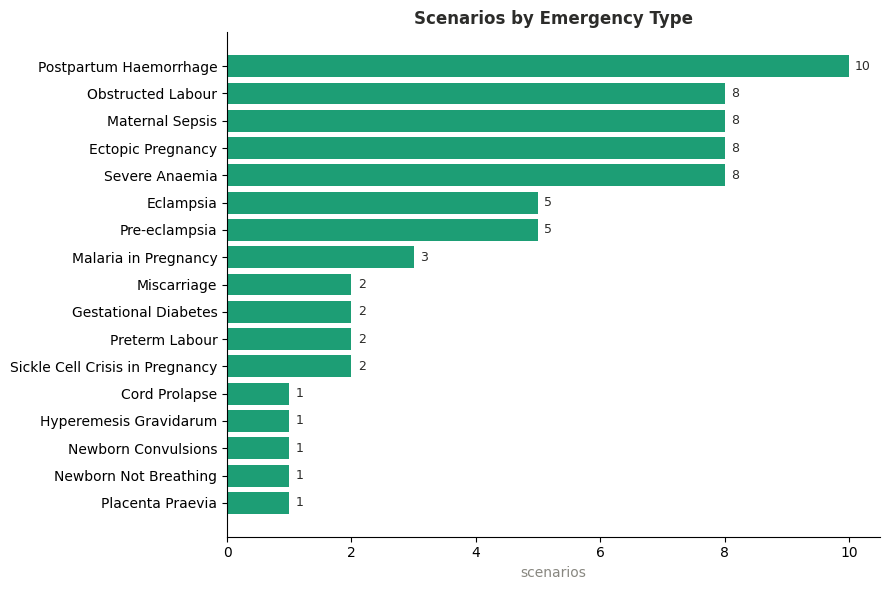

In [9]:
fig, ax = plt.subplots(figsize=(9,6))
vc = scen["emergency_type"].value_counts().sort_values()
ax.barh(vc.index, vc.values, color=GREEN)
for i,v in enumerate(vc.values): ax.text(v+0.1, i, str(v), va="center", fontsize=9, color=INK)
ax.set_title("Scenarios by Emergency Type", fontweight="bold", color=INK)
ax.set_xlabel("scenarios", color=GREY)
for s in ["top","right"]: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()

**Risk and severity** — note the skew toward High-risk / SMS-triggered cases. These are emergencies by design, so most should be high-acuity. This skew matters when reading evaluation results: a system that leans toward alerting will look accurate partly because most cases *should* alert, which is why results are read per emergency type, not just as one headline number.

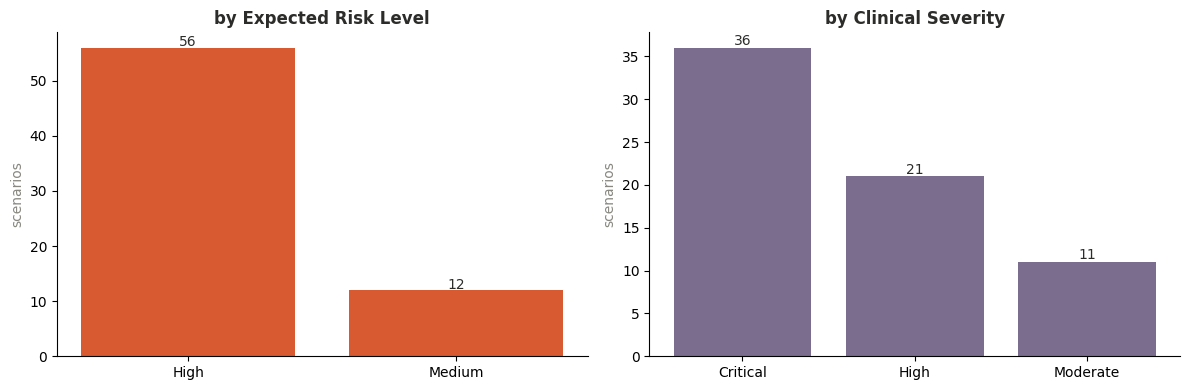

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(12,4))
for ax, colname, color, title in [
    (axs[0], "expected_risk_level", CORAL, "by Expected Risk Level"),
    (axs[1], "severity", PLUM, "by Clinical Severity"),
]:
    vc = scen[colname].value_counts()
    ax.bar(vc.index.astype(str), vc.values, color=color)
    for i,v in enumerate(vc.values): ax.text(i, v+0.3, str(v), ha="center", fontsize=10, color=INK)
    ax.set_title(title, fontweight="bold", color=INK); ax.set_ylabel("scenarios", color=GREY)
    for s in ["top","right"]: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.show()